# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

import torch
import torch.nn.parallel
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, Subset
import torch.optim as optim

from torchmetrics.image import  StructuralSimilarityIndexMeasure
from torchsummary import summary

import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils

from IPython.display import clear_output

# Set Random

In [2]:
random_seed = 42
random.seed(random_seed)
torch.manual_seed(random_seed)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Data

In [4]:
def get_fashion_mnist_0_and_1(root='./data', train=True, transform=None, download=True):
    # Load the Fashion MNIST dataset
    dataset = dset.FashionMNIST(root=root, train=train, transform=transform, download=download)
    
    # Filter the dataset to only include samples with labels 0 and 1
    targets = dataset.targets
    idx = (targets == 0) | (targets == 1)
    filtered_indices = torch.where(idx)[0]
    filtered_dataset = Subset(dataset, filtered_indices)
    
    return filtered_dataset

def get_dataloader(batch_size=64, root='./data'):
    # Define the transform
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
        # Transform to Gray Scale
        transforms.Grayscale(num_output_channels=1)
    ])
    
    # Get the filtered dataset
    train_dataset = get_fashion_mnist_0_and_1(root=root, train=True, transform=transform, download=True)
    test_dataset = get_fashion_mnist_0_and_1(root=root, train=False, transform=transform, download=True)
    
    # Combine dataset
    combined_dataset = torch.utils.data.ConcatDataset([train_dataset, test_dataset])
    
    # Split the dataset into train and val and test with 80%, 10%, and 10% of the data respectively
    train_ds, val_ds, test_ds = torch.utils.data.random_split(combined_dataset, [int(0.8 * len(combined_dataset)), int(0.1 * len(combined_dataset)), int(0.1 * len(combined_dataset))])
    
    # Create DataLoader
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=True)
    
    return train_loader, val_loader, test_loader

Using FashionMNIST dataset from pytorch because it's easier to lead and contain the same data, this can be seen from the downloaded dataset

In [5]:
train_loader, val_loader, test_loader = get_dataloader(batch_size=128)

# EDA

## Visualize Data (Train)

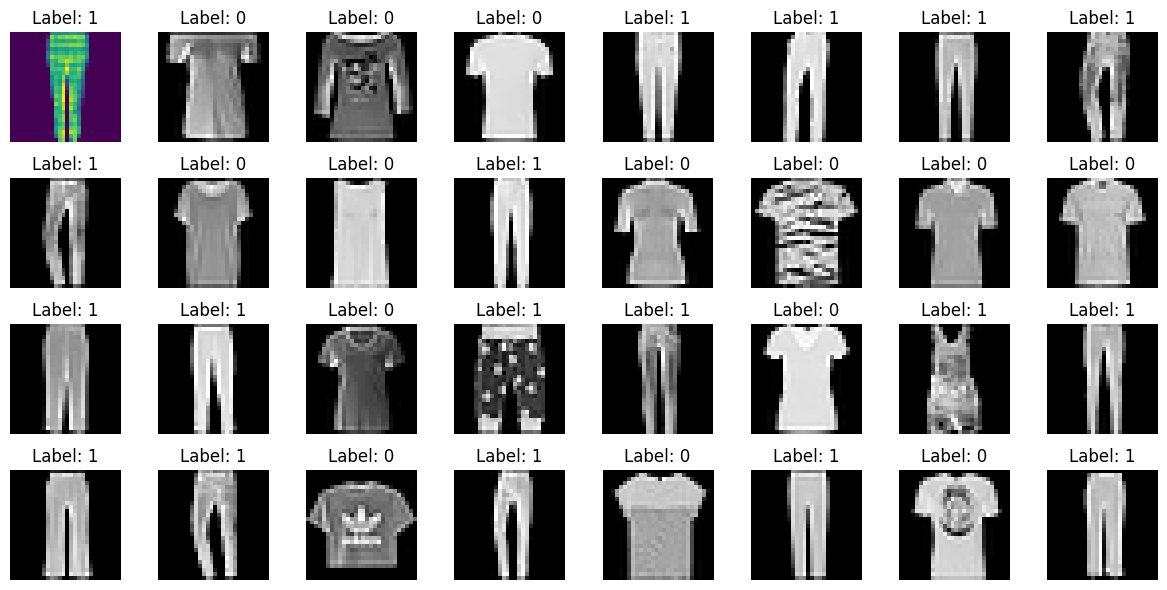

In [6]:
# Function to visualize data
def imshow(img, ax):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    ax.imshow(np.transpose(npimg, (1, 2, 0)))

# Get a batch of training data
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Visualize the data with labels
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
axes = axes.flatten()
for i in range(32):  # Display first 32 images
    img, label = images[i], labels[i].item()
    ax = axes[i]
    imshow(img, ax)
    plt.gray()
    ax.set_title(f'Label: {label}')
    ax.axis('off')

plt.tight_layout()
plt.show()

# Loss Function & Metrics

In [7]:
loss = nn.MSELoss()
ssim = StructuralSimilarityIndexMeasure()

loss.to(device)
ssim.to(device)

StructuralSimilarityIndexMeasure()

# Base AutoEncoder Model

In [8]:
class AutoEncoder(nn.Module) :
    def __init__(self) -> None:
        super(AutoEncoder, self).__init__()
        self.Encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(3,3), padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2)),
            nn.Flatten(),
            nn.Linear(6272, 128),
            nn.ReLU(),
        )
        self.Decoder = nn.Sequential(
            nn.Linear(128, 6272),
            nn.Unflatten(1, (32, 14, 14)),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(32, 32, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=2 , padding='same'),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = self.Encoder(x)
        x = self.Decoder(x)
        return x

## Compile Model

In [9]:
base_autoencoder = AutoEncoder().to(device)
summary(base_autoencoder, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
         MaxPool2d-3           [-1, 32, 14, 14]               0
           Flatten-4                 [-1, 6272]               0
            Linear-5                  [-1, 128]         802,944
              ReLU-6                  [-1, 128]               0
            Linear-7                 [-1, 6272]         809,088
         Unflatten-8           [-1, 32, 14, 14]               0
          Upsample-9           [-1, 32, 28, 28]               0
           Conv2d-10           [-1, 32, 28, 28]           9,248
             ReLU-11           [-1, 32, 28, 28]               0
           Conv2d-12            [-1, 1, 28, 28]             129
          Sigmoid-13            [-1, 1, 28, 28]               0
Total params: 1,621,729
Trainable param

c:\Users\kanek\miniconda3\envs\PyTorch-DL\Lib\site-packages\torch\nn\modules\conv.py:456: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\Convolution.cpp:1032.)
  return F.conv2d(input, weight, bias, self.stride,


## Compile Model

In [10]:
base_model_optimizer = optim.Adam(base_autoencoder.parameters(), lr=0.001)

## Fit Model

### Train Function

In [11]:
def train(model, optimizer, loss_fn, loader, device):
    epoch_loss = 0.0
    model.train()

    for x, _ in tqdm(loader):
        x = x.to(device, dtype=torch.float32)
        optimizer.zero_grad()
        
        output = model(x)  # Split the output of the model
        loss = loss_fn(output, x) # Calculate the loss
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    return epoch_loss / len(loader)

    

### Validation Function

In [12]:
def valid(model, loader, loss_fn, device):
    epoch_loss = 0.0
    model.eval()

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device, dtype=torch.float32)
            
            output = model(x) 
            loss = loss_fn(output, x)
            epoch_loss += loss.item()

    return epoch_loss / len(loader)

### Train Model

In [13]:
checkpoints_path = 'base_autoencoder.pth'
epochs = 50


best_val_loss = float('inf')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_losses = []
val_losses = []
num_no_improve = 0

for epoch in range(epochs):
    train_loss = train(base_autoencoder, base_model_optimizer, loss, train_loader, device) 
    val_loss = valid(base_autoencoder, val_loader, loss, device) 
    
    train_losses.append(train_loss) 
    val_losses.append(val_loss)  
    
    clear_output(wait=True)
    print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}')
    print(f'Validation Loss: {val_loss:.4f}')
    
    if val_loss < best_val_loss:  
        best_val_loss = val_loss
        print("Saving the model")
        torch.save(base_autoencoder.state_dict(), checkpoints_path) 
    else:
        print("Model not saved")
        num_no_improve += 1
            
    if num_no_improve >= 5:
        print("Early stopping")
        break

Epoch 32/50, Train Loss: 0.5961
Validation Loss: 0.5978
Model not saved
Early stopping


## Evaluate Model

### Plot Training History

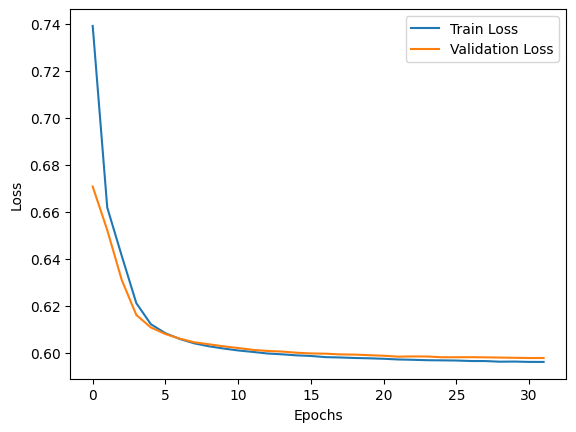

In [14]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

# Tune Model

- More Epochs
- load best weights from checkpoint
- Learning Rate Scheduler

## Learning Rate Scheduler

In [15]:
tuned_autoencoder = AutoEncoder().to(device)
tuned_autoencoder.load_state_dict(torch.load(checkpoints_path))
tuned_optimizer = optim.Adam(tuned_autoencoder.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.LinearLR(tuned_optimizer, start_factor=1.0, end_factor=0.3, total_iters=10)

## Train Model

In [16]:
checkpoints_path = 'tuned_autoencoder.pth'
epochs = 100

best_val_loss = best_val_loss
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_losses = []
val_losses = []
num_no_improve = 0

for epoch in range(epochs):
    train_loss = train(base_autoencoder, base_model_optimizer, loss, train_loader, device) 
    val_loss = valid(base_autoencoder, val_loader, loss, device) 
    
    train_losses.append(train_loss) 
    val_losses.append(val_loss)  
    
    clear_output(wait=True)
    print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}')
    print(f'Validation Loss: {val_loss:.4f}')
    
    before = tuned_optimizer.param_groups[0]['lr']
    scheduler.step()
    after = tuned_optimizer.param_groups[0]['lr']
    
    if val_loss < best_val_loss:  
        best_val_loss = val_loss
        print("Saving the model")
        torch.save(base_autoencoder.state_dict(), checkpoints_path) 
    
    if len(val_losses) > 1: 
        if val_loss <= best_val_loss: 
            num_no_improve += 1
        else:
            num_no_improve = 0
            
    if num_no_improve >= 3:
        print("Early stopping")
        break

Epoch 30/100, Train Loss: 0.5948
Validation Loss: 0.5970
Saving the model
Early stopping


# Evaluate Tuned Model

## Model History

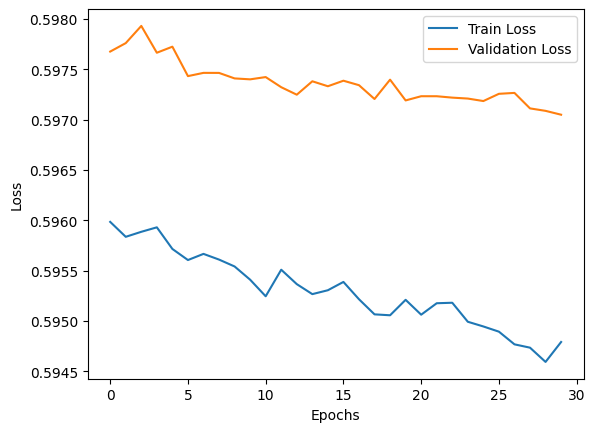

In [17]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()


## Model Inference

### Load Best Model

In [18]:
best_autoencoder = AutoEncoder().to(device)
best_autoencoder.load_state_dict(torch.load(checkpoints_path))

<All keys matched successfully>

In [19]:
test_loss = valid(best_autoencoder, test_loader, loss, device)
print(f'Test Loss: {test_loss:.4f}')

Test Loss: 0.5920


In [20]:
test_ssims = []
output_images = []
best_autoencoder.eval()
with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device, dtype=torch.float32)
        output = best_autoencoder(x)
        output_images.append(output)
        test_ssims.append(ssim(output, x).item())
        
print(f'Mean SSIM: {np.mean(test_ssims):.4f}')

Mean SSIM: 0.1563


### Visualize Model Inference (Predictions)

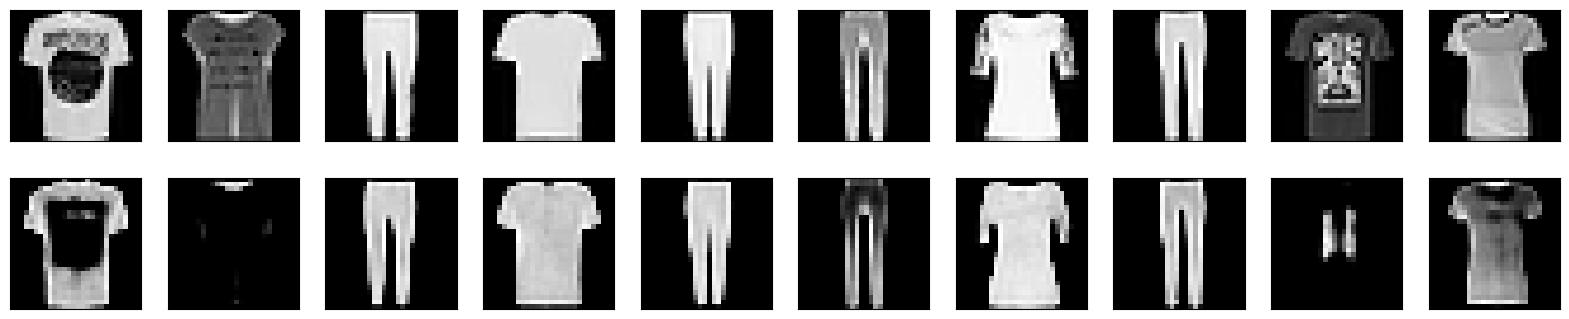

In [21]:
def predict(model, loader, device):
    model.eval()
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device, dtype=torch.float32)
            output = model(x)
            return output, x
        
output_images, real_images = predict(best_autoencoder, test_loader, device)

# Show predicted vs original images
plt.figure(figsize=(20, 4))
for i in range(10):
    # Display original
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(real_images[i].cpu().numpy().squeeze())
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(2, 10, i + 1 + 10)
    plt.imshow(output_images[i].cpu().numpy().squeeze())
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    


# Conclusion

The model is unable to reconstruct the images correctly seen from the mean SSIM is 0.15 meaning 85% of the information inside the images is lost during the reconstruction process. This is due to the model being too simple and unable to capture the complexity of the images.